# Station

In [15]:
site = atmms.Station(
        lat=40.0,
        lon=-105.0,
        alt=1600,
        name="Boulder",
        abbreviation="BOU",
    )

In [16]:
site.get_sun_position('2025-05-13 18:00:00')

original columns: ['apparent_zenith', 'zenith', 'apparent_elevation', 'elevation', 'azimuth', 'equation_of_time']


<xarray.Dataset> Size: 80B
Dimensions:              (datetime: 1)
Coordinates:
  * datetime             (datetime) datetime64[us] 8B 2025-05-13T18:00:00
Data variables:
    zenith               (datetime) float64 8B 0.4296
    zenith_geometric     (datetime) float64 8B 0.4297
    elevation            (datetime) float64 8B 1.141
    elevation_geometric  (datetime) float64 8B 1.141
    azimuth              (datetime) float64 8B 2.555
    equation_of_time     (datetime) float64 8B 3.675
    airmass              (datetime) float64 8B 1.099
    airmass_absolute     (datetime) float64 8B 0.9062
    sun_earth_distance   (datetime) float64 8B 1.01
Attributes:
    Conventions:  CF-1.13
    title:        Solar position, air mass, and Sun–Earth distance from pvlib
    source:       pvlib

In [18]:
site.plot()

ImportError: cartopy is required for this feature. Please install it to use this functionality.

# moving plattform

In [3]:
import pandas as pd
import atmPy.general.measurement_site as atmms

In [4]:
reload(atmms)

<module 'atmPy.general.measurement_site' from '/Users/htelg/prog/atm-py/atmPy/general/measurement_site.py'>

In [5]:
# A simple west-to-east flight path crossing timezone boundaries.
track_time = pd.date_range(
    "2024-06-21 16:00:00",
    periods=7,
    freq="30min",
)
track_time.name = 'datetime'

platform = atmms.MovingPlatform(
    lat=pd.Series([39.7, 40.0, 40.4, 40.8, 41.1, 41.4, 41.7], index=track_time).to_xarray(),
    lon=pd.Series([-108.0, -106.0, -104.0, -101.0, -98.0, -95.0, -92.0], index=track_time).to_xarray(),
    alt=pd.Series([1600, 2200, 3200, 4500, 5200, 4800, 3500], index=track_time).to_xarray(),
    name="Evaluation Flight",
    abbreviation="EVAL",
)
self = platform

(<Figure size 640x480 with 1 Axes>, <GeoAxes: >)

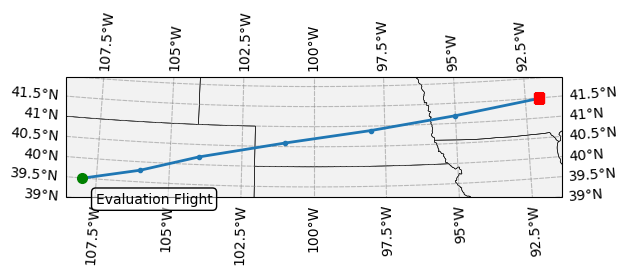

In [6]:
platform.plot_path()

In [7]:
platform.sun_position

<xarray.Dataset> Size: 560B
Dimensions:              (datetime: 7)
Coordinates:
  * datetime             (datetime) datetime64[us] 56B 2024-06-21T16:00:00 .....
Data variables:
    zenith               (datetime) float64 56B 0.764 0.6401 ... 0.3149 0.367
    zenith_geometric     (datetime) float64 56B 0.7643 0.6403 ... 0.3149 0.3671
    elevation            (datetime) float64 56B 0.8068 0.9307 ... 1.256 1.204
    elevation_geometric  (datetime) float64 56B 0.8065 0.9305 ... 1.256 1.204
    azimuth              (datetime) float64 56B 1.69 1.831 2.015 ... 3.245 3.728
    equation_of_time     (datetime) float64 56B -1.954 -1.959 ... -1.977 -1.981
    airmass              (datetime) float64 56B 1.383 1.246 ... 1.051 1.071
    airmass_absolute     (datetime) float64 56B 1.14 0.9534 ... 0.5756 0.695
    sun_earth_distance   (datetime) float64 56B 1.016 1.016 ... 1.016 1.016
Attributes:
    Conventions:  CF-1.13
    title:        Solar position, air mass, and Sun–Earth distance from pvlib
    source:       pvlib

In [8]:
platform.time_zone

<xarray.Dataset> Size: 280B
Dimensions:                    (datetime: 7)
Coordinates:
  * datetime                   (datetime) datetime64[us] 56B 2024-06-21T16:00...
Data variables:
    tz_str                     (datetime) object 56B 'America/Denver' ... 'Am...
    tz_name                    (datetime) object 56B 'MDT' 'MDT' ... 'CDT' 'CDT'
    diff2UTC                   (datetime) float64 56B -6.0 -6.0 ... -5.0 -5.0
    diff2UTC_of_standard_time  (datetime) float64 56B -7.0 -7.0 ... -6.0 -6.0